In [47]:
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import shap

In [48]:
# load the data
data = pd.read_excel('../data/Featurized Polymer SAXS Data.xlsx')

# drop the rows that do not have Rg value (if any)
data = data.dropna(subset=['Final Rg'])

print(f"Total number of samples: {data['Final Rg'].notnull().sum()}")
print(f"Total number of unique polymers: {data['Polymer_ID'].nunique()}") # should be 171 if grouped correctly


Total number of samples: 493
Total number of unique polymers: 171


In [49]:
# set target and threshold
target = 'Final Rg'
mean_rg = round(data[target].mean(), 1)
threshold = 72.33
print(f"Mean Rg: {mean_rg:.1f} nm, Threshold for classification: {threshold:.1f} nm")


# Create binary target: 1 if larger, 0 if smaller or equal
data['Rg_bin'] = (data['Final Rg'] > threshold).astype(int)

# set initial features
potential_features = ['Concentration',  'Total Charge', 'Net Charge', 
                      'LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 
                      'HBD', 'HBA', 'HBT', 'HBDiff', 'HBR', 'Neutral Fraction']


# Select features and target
features = potential_features
X = data[features].copy()
y = data['Rg_bin']
groups = data['Polymer_ID']

# Drop rows with missing values in X and update y and groups accordingly
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]
groups = groups.loc[valid_idx]

print(y.value_counts())

print(f"Number of usable samples: {len(X)}")
print(f"Number of unique polymers in usable samples: {data.loc[X.index, 'Polymer_ID'].nunique()}")
print(f"Number of groups in usable samples: {groups.nunique()}")

Mean Rg: 72.3 nm, Threshold for classification: 72.3 nm
Rg_bin
0    256
1    236
Name: count, dtype: int64
Number of usable samples: 492
Number of unique polymers in usable samples: 171
Number of groups in usable samples: 171


In [50]:
# prep for data splitting

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"Fold {fold}: Train groups = {groups.iloc[train_idx].nunique()}, Test groups = {groups.iloc[test_idx].nunique()}")

Fold 1: Train groups = 137, Test groups = 34
Fold 2: Train groups = 136, Test groups = 35
Fold 3: Train groups = 137, Test groups = 34
Fold 4: Train groups = 137, Test groups = 34
Fold 5: Train groups = 137, Test groups = 34


In [51]:
# trying a few  classifiers to see which works best

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(probability=True)
}

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Feature selection on training set
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rfe = RFE(clf, n_features_to_select=4)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_].tolist()
    print("Selected features:", selected_features)

    for name, model in models.items():
        model.fit(X_train[selected_features], y_train)
        y_pred = model.predict(X_test[selected_features])
        print(f"\n{name}")
        print(classification_report(y_test, y_pred))
        print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")


Fold 1
Selected features: ['Net Charge', 'Molecular Weight (Da)', 'HBT', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

           0       0.66      0.85      0.74        47
           1       0.82      0.60      0.69        52

    accuracy                           0.72        99
   macro avg       0.74      0.72      0.71        99
weighted avg       0.74      0.72      0.71        99

Balanced accuracy: 0.724

Random Forest
              precision    recall  f1-score   support

           0       0.64      0.62      0.63        47
           1       0.67      0.69      0.68        52

    accuracy                           0.66        99
   macro avg       0.66      0.65      0.65        99
weighted avg       0.66      0.66      0.66        99

Balanced accuracy: 0.655

XGBoost
              precision    recall  f1-score   support

           0       0.63      0.66      0.65        47
           1       0.68      0.65      0.67     

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:05:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['Net Charge', 'Molecular Weight (Da)', 'HBT', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        54
           1       0.80      0.80      0.80        45

    accuracy                           0.82        99
   macro avg       0.82      0.82      0.82        99
weighted avg       0.82      0.82      0.82        99

Balanced accuracy: 0.817

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.61      0.73        54
           1       0.66      0.91      0.77        45

    accuracy                           0.75        99
   macro avg       0.78      0.76      0.75        99
weighted avg       0.79      0.75      0.74        99

Balanced accuracy: 0.761

XGBoost
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        54
           1       0.75      0.80      0.77        45

 

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:05:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['LogP', 'Molecular Weight (Da)', 'HBT', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.81      0.78        57
           1       0.70      0.63      0.67        41

    accuracy                           0.73        98
   macro avg       0.73      0.72      0.72        98
weighted avg       0.73      0.73      0.73        98

Balanced accuracy: 0.721

Random Forest
              precision    recall  f1-score   support

           0       0.71      0.56      0.63        57
           1       0.53      0.68      0.60        41

    accuracy                           0.61        98
   macro avg       0.62      0.62      0.61        98
weighted avg       0.63      0.61      0.61        98

Balanced accuracy: 0.622

XGBoost
              precision    recall  f1-score   support

           0       0.71      0.72      0.71        57
           1       0.60      0.59      0.59        41

    acc

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:05:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['Net Charge', 'Molecular Weight (Da)', 'HBA', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        50
           1       0.80      0.81      0.80        48

    accuracy                           0.81        98
   macro avg       0.81      0.81      0.81        98
weighted avg       0.81      0.81      0.81        98

Balanced accuracy: 0.806

Random Forest
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        50
           1       0.77      0.77      0.77        48

    accuracy                           0.78        98
   macro avg       0.78      0.78      0.78        98
weighted avg       0.78      0.78      0.78        98

Balanced accuracy: 0.775

XGBoost
              precision    recall  f1-score   support

           0       0.72      0.92      0.81        50
           1       0.88      0.62      0.73        48

 

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:05:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['Molecular Weight (Da)', 'HBT', 'HBR', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

           0       0.58      0.71      0.64        48
           1       0.64      0.50      0.56        50

    accuracy                           0.60        98
   macro avg       0.61      0.60      0.60        98
weighted avg       0.61      0.60      0.60        98

Balanced accuracy: 0.604

Random Forest
              precision    recall  f1-score   support

           0       0.58      0.71      0.64        48
           1       0.64      0.50      0.56        50

    accuracy                           0.60        98
   macro avg       0.61      0.60      0.60        98
weighted avg       0.61      0.60      0.60        98

Balanced accuracy: 0.604

XGBoost
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        48
           1       0.57      0.48      0.52        50

    accu

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [52]:
# tabular results of balanced accuracy for each model and fold, with average at the end

results = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Feature selection on training set
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rfe = RFE(clf, n_features_to_select=4)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_].tolist()

    for name, model in models.items():
        model.fit(X_train[selected_features], y_train)
        y_pred = model.predict(X_test[selected_features])
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        results.append({
            'Fold': fold,
            'Model': name,
            'Balanced Accuracy': bal_acc
        })
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Fold', columns='Model', values='Balanced Accuracy')
print(pivot_df)
print("\nAverage Balanced Accuracy:")
print(pivot_df.mean())

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Model  Logistic Regression  Random Forest       SVM   XGBoost
Fold                                                         
1                 0.723609       0.654664  0.524550  0.656710
2                 0.816667       0.761111  0.657407  0.788889
3                 0.720582       0.622165  0.461275  0.652332
4                 0.806250       0.775417  0.677083  0.772500
5                 0.604167       0.604167  0.639583  0.552500

Average Balanced Accuracy:
Model
Logistic Regression    0.734255
Random Forest          0.683505
SVM                    0.591980
XGBoost                0.684586
dtype: float64


c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Running 5-fold cross-validation with concatenated predictions...
Fold 1: Balanced Accuracy = 0.649, Test Samples = 99
Fold 2: Balanced Accuracy = 0.819, Test Samples = 99
Fold 3: Balanced Accuracy = 0.658, Test Samples = 98
Fold 4: Balanced Accuracy = 0.867, Test Samples = 98
Fold 5: Balanced Accuracy = 0.664, Test Samples = 98
OVERALL RESULTS (All 5 Folds Combined):
Total samples: 492
Overall Balanced Accuracy: 0.732

Overall Classification Report:
              precision    recall  f1-score   support

     Ordered       0.73      0.77      0.75       256
  Disordered       0.73      0.70      0.72       236

    accuracy                           0.73       492
   macro avg       0.73      0.73      0.73       492
weighted avg       0.73      0.73      0.73       492



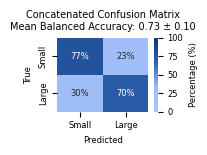


Individual Fold Results:
   Fold  Balanced_Accuracy  Test_Samples  Balanced_Accuracy_Rounded
0     1           0.649141            99                      0.649
1     2           0.818519            99                      0.819
2     3           0.657681            98                      0.658
3     4           0.867500            98                      0.867
4     5           0.663750            98                      0.664

Mean Balanced Accuracy across folds: 0.73 ± 0.10

Confusion Matrix (Counts):
                 Predicted
True    Small  Large
Small    196       60
Large  71      165

Confusion Matrix (Percentages):
                 Predicted
True    Small  Large
Small    76.6%     23.4%
Large  30.1%     69.9%


In [53]:
# Concatenated confusion matrix across all 5 folds

# Set the features and model
selected_features = ['LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 'HBA']

# Initialize lists to collect all predictions and true values
all_y_true = []
all_y_pred = []
fold_results = []

print("Running 5-fold cross-validation with concatenated predictions...")
print("=" * 60)

# Run through all 5 folds
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    # Create model for this fold
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    
    # Split data for this fold
    X_train_fold = X.iloc[train_idx][selected_features]
    X_test_fold = X.iloc[test_idx][selected_features]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]
    
    # Fit and predict
    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)
    
    # Calculate balanced accuracy for this fold
    fold_balanced_acc = balanced_accuracy_score(y_test_fold, y_pred_fold)
    
    # Store results
    fold_results.append({
        'Fold': fold,
        'Balanced_Accuracy': fold_balanced_acc,
        'Test_Samples': len(y_test_fold)
    })
    
    # Add to concatenated lists
    all_y_true.extend(y_test_fold.tolist())
    all_y_pred.extend(y_pred_fold.tolist())
    
    print(f"Fold {fold}: Balanced Accuracy = {fold_balanced_acc:.3f}, Test Samples = {len(y_test_fold)}")

print("=" * 60)

# Convert to numpy arrays for easier manipulation
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Calculate overall metrics
overall_balanced_acc = balanced_accuracy_score(all_y_true, all_y_pred)
overall_balanced_std = np.std([result['Balanced_Accuracy'] for result in fold_results])
overall_cm = confusion_matrix(all_y_true, all_y_pred)

print(f"OVERALL RESULTS (All 5 Folds Combined):")
print(f"Total samples: {len(all_y_true)}")
print(f"Overall Balanced Accuracy: {overall_balanced_acc:.3f}")
print(f"\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=['Ordered', 'Disordered']))

# Create the concatenated confusion matrix visualization
colors = ['#FFFFFF','#457b3a']
sunset = ['#A5C6FF', '#9EBCF5', '#2D5FAC', '#0D397B', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", sunset[0:4])

# Calculate percentage confusion matrix (normalize by true class)
cm_percent = overall_cm.astype('float') / overall_cm.sum(axis=1)[:, np.newaxis] * 100

# Create custom annotations with % signs
annot_labels = np.array([[f'{val:.0f}%' for val in row] for row in cm_percent])

shape_confusion = plt.figure(figsize=(2, 1.65))
ax = sns.heatmap(cm_percent, annot_kws={'fontsize': 6}, annot=annot_labels, fmt='', cmap=custom_cmap,
            xticklabels=['Small', 'Large'], 
            yticklabels=['Small', 'Large'],
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)

ax.tick_params(axis='both', which='major', labelsize=6)

# 4. Set fontsize for Colorbar Label and Ticks
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=6) # Ticks (0, 20, ..., 100)
cbar.set_label('Percentage (%)', fontsize=6) # Label ('Percentage (%)')

fold_df = pd.DataFrame(fold_results)
mean_acc = fold_df['Balanced_Accuracy'].mean()
std_acc = fold_df['Balanced_Accuracy'].std()

plt.xlabel('Predicted', fontsize=6)
plt.ylabel('True', fontsize=6)
plt.title('Concatenated Confusion Matrix\nMean Balanced Accuracy: {:.2f} ± {:.2f}'.format(mean_acc, std_acc), fontsize=7)
plt.tight_layout()
plt.show()

# save the figure in high res
shape_confusion.savefig('../imgs/size classification/size classifier confusion matrix.svg', dpi=600, bbox_inches='tight', transparent=True)

# Show individual fold results
fold_df = pd.DataFrame(fold_results)
fold_df['Balanced_Accuracy_Rounded'] = fold_df['Balanced_Accuracy'].round(3)
print(f"\nIndividual Fold Results:")
print(fold_df)
print(f"\nMean Balanced Accuracy across folds: {fold_df['Balanced_Accuracy'].mean():.2f} ± {fold_df['Balanced_Accuracy'].std():.2f}")

print(f"\nConfusion Matrix (Counts):")
print(f"                 Predicted")
print(f"True    Small  Large")
print(f"Small    {overall_cm[0,0]:3d}      {overall_cm[0,1]:3d}")
print(f"Large {overall_cm[1,0]:3d}      {overall_cm[1,1]:3d}")

print(f"\nConfusion Matrix (Percentages):")
print(f"                 Predicted")
print(f"True    Small  Large")
print(f"Small   {cm_percent[0,0]:5.1f}%    {cm_percent[0,1]:5.1f}%")
print(f"Large {cm_percent[1,0]:5.1f}%    {cm_percent[1,1]:5.1f}%")

Creating SHAP summary plot for concatenated cross-validation results...
Computing SHAP values for Fold 1...
Computing SHAP values for Fold 2...
Computing SHAP values for Fold 3...
Computing SHAP values for Fold 4...
Computing SHAP values for Fold 5...
Total test samples across all folds: 492
SHAP values shape: (492, 4)
Features: ['LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 'HBA']


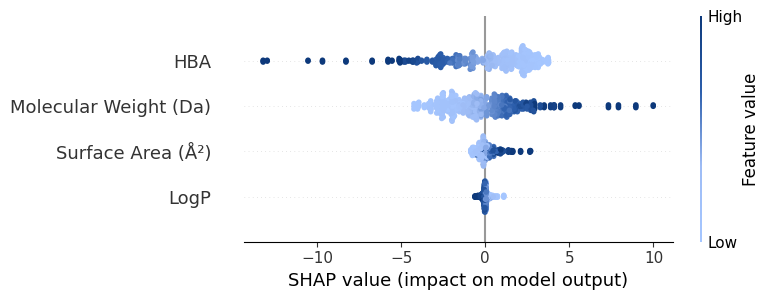

SHAP analysis complete!
The plot shows feature importance and impact across all 492 test samples
from the 5-fold cross-validation.


In [54]:
# SHAP summary plot for concatenated 5-fold cross-validation results

print("Creating SHAP summary plot for concatenated cross-validation results...")
print("=" * 60)

# Collect all test data and SHAP values across all folds
all_X_test = []
all_shap_values = []

# Re-run through folds to collect SHAP data
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"Computing SHAP values for Fold {fold}...")
    
    # Create model for this fold
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    
    # Split data for this fold
    X_train_fold = X.iloc[train_idx][selected_features]
    X_test_fold = X.iloc[test_idx][selected_features]
    y_train_fold = y.iloc[train_idx]
    
    # Fit model
    model.fit(X_train_fold, y_train_fold)
    
    # Create SHAP explainer and calculate SHAP values
    explainer = shap.Explainer(model, X_train_fold)
    shap_values_fold = explainer(X_test_fold)
    
    # Store the test data and SHAP values
    all_X_test.append(X_test_fold)
    all_shap_values.append(shap_values_fold.values)

# Concatenate all test data and SHAP values
X_test_concatenated = pd.concat(all_X_test, axis=0)
shap_values_concatenated = np.concatenate(all_shap_values, axis=0)

print(f"Total test samples across all folds: {len(X_test_concatenated)}")
print(f"SHAP values shape: {shap_values_concatenated.shape}")
print(f"Features: {list(X_test_concatenated.columns)}")

# Create the SHAP summary plot with custom colors
sunset_blues = ['#A5C6FF', '#9EBCF5', '#2D5FAC', '#0D397B' ]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", sunset_blues[0:])

size = plt.figure(figsize=(3, 2))
shap.summary_plot(shap_values_concatenated, X_test_concatenated, 
                  cmap=custom_cmap, 
                  feature_names=X_test_concatenated.columns,
                  show=False)
#plt.title('SHAP Summary Plot - Concatenated 5-Fold Cross-Validation\n(All Test Predictions Combined)', 
          #fontsize=6, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# save 
size.savefig('../imgs/size classification/size classifier shap summary.svg', dpi=600, bbox_inches='tight', transparent=True)

print("=" * 60)
print("SHAP analysis complete!")
print(f"The plot shows feature importance and impact across all {len(X_test_concatenated)} test samples")
print("from the 5-fold cross-validation.")